## Imports and paths

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from matplotlib.ticker import FuncFormatter


pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

In [5]:
# File paths
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "Cleaned Data" / "004 Split"
RESULT_DIR = PROJECT_DIR / "Result" / "Random Forest"
FIGURE_DIR = RESULT_DIR / "Figures"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
# 6 Countries
COUNTRIES = {"AUS": "Australia","BRA": "Brazil","CAN": "Canada","GBR": "United Kingdom","IND": "India","USA": "United States"}

# Model settings
RANDOM_STATE = 1948883                                                                              # Seed                                                 
N_SPLITS = 5                                                                                        # 5-fold CV
N_ITER_SEARCH = 40                                                                                  # 40 hyperparameter combinations
PERIOD_LABELS = {"before_mandate": "Before mandate","after_mandate": "After mandate"}               # Mandate periods
TASK_TYPES = {"mask": "Face mask wearing","protective": "Protective behaviour"}                     # 2 Outcomes

# Visualisation settings
TOP_N_FEATURES = 10                                                                                 # Top 10 feature importancs
SAVE_FIGURES = True                                                                                 # Save figures

## 1 Helper functions

In [7]:
# Read 4 csvs 
def load_task(country_name, task_name):
    safe_country_name = country_name.replace(" ", "_")
    task_dir = DATA_DIR / safe_country_name                                                                                 # Files 

    X_train = pd.read_csv(task_dir / f"X_train_{task_name}.csv", encoding="utf-8-sig")                                      # Predictors of the train set
    X_test = pd.read_csv(task_dir / f"X_test_{task_name}.csv", encoding="utf-8-sig")                                        # Predictors of the test set
    y_train = (pd.read_csv(task_dir / f"y_train_{task_name}.csv", encoding="utf-8-sig").iloc[:, 0].astype(int))             # Outcomes of the train set
    y_test = (pd.read_csv(task_dir / f"y_test_{task_name}.csv", encoding="utf-8-sig").iloc[:, 0].astype(int))               # Outcomes of the test set

    return X_train, X_test, y_train, y_test                                                                                 # Return


# Random Forest Pipeline
def build_pipeline():
    return Pipeline(steps=[("ros", RandomOverSampler(random_state=RANDOM_STATE)),                                                  # Processing class imbalance
                            ("model", RandomForestClassifier( n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1,))])          # Train model


# Hyperparameter search
def Param_distributions():
    return {
        "model__max_depth": [5, 8, 10, 12, 15, 20, None],                               # Max depth
        "model__min_samples_split": [2, 5, 10, 20, 30],                                 # Min samples split
        "model__min_samples_leaf": [1, 2, 5, 10],                                       # Min samples leaf
        "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],                   # Max features
        "model__bootstrap": [True]}                                                     # Boot



def build_search(y_train):
    min_class_count = y_train.value_counts().min()                                          # Check the number of minority class samples in the train set
    if min_class_count < 2:
        raise ValueError("No enough samples")
    
    n_splits = min(N_SPLITS, min_class_count)                                               # 5-fold CV      
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE,)       # 5-fold CV: Hierarchical cross-validation

    # Random search 40 combinations of hyperparameters
    search = RandomizedSearchCV(estimator=build_pipeline(), param_distributions=Param_distributions(), n_iter=N_ITER_SEARCH, scoring="roc_auc", cv=cv, random_state=RANDOM_STATE, n_jobs=1, refit=True, verbose=0, return_train_score=False)

    return search


# Calculate AUC
def roc_auc(y_true, y_prob):

    if pd.Series(y_true).nunique() < 2:                     # If all "0" or "1"
        return np.nan                                       # Error

    return roc_auc_score(y_true, y_prob)


# Calculate feature importance
def Feature_importance(best_model, feature_names):

    fitted_model = best_model.named_steps["model"]                                                                          # Use best modedl

    importance_df = pd.DataFrame({"feature": list(feature_names), "importance": fitted_model.feature_importances_})         # Extract values ​​and save
    importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)                         # Sort
    importance_df["rank"] = np.arange(1, len(importance_df) + 1)                                                            # Add ranking

    return importance_df

## 2 Train models

In [8]:
auc_results = []                                # AUC storage
feature_importance_results = []                 # Feature importance storage

for code, country_name in COUNTRIES.items():                                # Country loop

    safe_country_name = country_name.replace(" ", "_")            

    for period_label in PERIOD_LABELS.keys():                               # Period loop
        for task_type in TASK_TYPES.keys():                                 # Task loop

            task_name = f"{safe_country_name}_{period_label}_{task_type}"                                                   # Task name
            task_label = f"{country_name} - {PERIOD_LABELS[period_label]} - {TASK_TYPES[task_type]}"                        # Task label

            print(f"Running: {task_label}")                     

            try:
                X_train, X_test, y_train, y_test = load_task(country_name=country_name, task_name=task_name)                # Load data

                search = build_search(y_train)                              # Build search
                search.fit(X_train, y_train)                                # Train model
                best_model = search.best_estimator_                         # Best model
                y_test_prob = best_model.predict_proba(X_test)[:, 1]       

                # ORC AUC
                auc_row = {  "model": "Random Forest", "country": country_name, "mandate_period": period_label, "mandate_period_label": PERIOD_LABELS[period_label], "task_type": task_type, "outcome": TASK_TYPES[task_type], "task_name": task_name, "task_label": task_label, "cv_roc_auc": search.best_score_, "test_roc_auc": roc_auc(y_test, y_test_prob)}
                auc_results.append(auc_row)          

                importance_df = Feature_importance(best_model=best_model, feature_names=X_train.columns)                # Feature importance

                importance_df.insert(0, "model", "Random Forest")                                                           # Add model
                importance_df.insert(1, "country", country_name)                                                            # Add country
                importance_df.insert(2, "mandate_period", period_label)                                                     # Add period
                importance_df.insert(3, "mandate_period_label", PERIOD_LABELS[period_label])  # Add period label
                importance_df.insert(4, "task_type", task_type)                                                             # Add task
                importance_df.insert(5, "outcome", TASK_TYPES[task_type])                                                   # Add outcome
                importance_df.insert(6, "task_name", task_name)                                                             # Add task name
                importance_df.insert(7, "task_label", task_label)                                                           # Add task label
                feature_importance_results.append(importance_df)      

                print(f"Completed {task_name}: "f"CV ROC AUC = {auc_row['cv_roc_auc']:.4f}, "f"Test ROC AUC = {auc_row['test_roc_auc']:.4f}")     

            except FileNotFoundError:
                print(f"Skipped {task_name}: not found")     

            except ValueError as e:
                print(f"Skipped {task_name}: {e}")               


auc_df = pd.DataFrame(auc_results)                                                   # AUC table
feature_importance_df = pd.concat(feature_importance_results,ignore_index=True)      # Feature importance table

auc_df.to_csv( RESULT_DIR / "random_forest_auc_results.csv",index=False,encoding="utf-8-sig")                                   # Save AUC
feature_importance_df.to_csv(RESULT_DIR / "random_forest_feature_importance_all.csv",index=False,encoding="utf-8-sig")          # Save Feature importance

Running: Australia - Before mandate - Face mask wearing
Completed Australia_before_mandate_mask: CV ROC AUC = 0.8442, Test ROC AUC = 0.8438
Running: Australia - Before mandate - Protective behaviour
Completed Australia_before_mandate_protective: CV ROC AUC = 0.7737, Test ROC AUC = 0.7666
Running: Australia - After mandate - Face mask wearing
Completed Australia_after_mandate_mask: CV ROC AUC = 0.9017, Test ROC AUC = 0.9094
Running: Australia - After mandate - Protective behaviour
Completed Australia_after_mandate_protective: CV ROC AUC = 0.8186, Test ROC AUC = 0.8256
Running: Brazil - Before mandate - Face mask wearing
Completed Brazil_before_mandate_mask: CV ROC AUC = 0.7848, Test ROC AUC = 0.7833
Running: Brazil - Before mandate - Protective behaviour
Completed Brazil_before_mandate_protective: CV ROC AUC = 0.7756, Test ROC AUC = 0.7125
Running: Brazil - After mandate - Face mask wearing
Completed Brazil_after_mandate_mask: CV ROC AUC = 0.7911, Test ROC AUC = 0.6516
Running: Brazil -

## 3 Visualisation

### 3.1 AUC results

In [9]:
# ROC AUC
auc_display = (
    auc_df.assign(outcome_period=lambda d: d["outcome"] + " — " + d["mandate_period_label"])
    [["country", "outcome_period", "cv_roc_auc", "test_roc_auc",]].sort_values(["country", "outcome_period"]))

display(auc_display.round(4))

,country,outcome_period,cv_roc_auc,test_roc_auc
2,Australia,Face mask wearing — After mandate,0.9017,0.9094
0,Australia,Face mask wearing — Before mandate,0.8442,0.8438
3,Australia,Protective behaviour — After mandate,0.8186,0.8256
1,Australia,Protective behaviour — Before mandate,0.7737,0.7666
6,Brazil,Face mask wearing — After mandate,0.7911,0.6516
4,Brazil,Face mask wearing — Before mandate,0.7848,0.7833
7,Brazil,Protective behaviour — After mandate,0.8135,0.8287
5,Brazil,Protective behaviour — Before mandate,0.7756,0.7125
10,Canada,Face mask wearing — After mandate,0.8242,0.8419
8,Canada,Face mask wearing — Before mandate,0.8359,0.8421


### 3.2 Feature importance

#### 3.2.1 Help functions

In [10]:
# Category
CATEGORY_ORDER = ["Demographics",                   "Self-protective behaviours",                  "Perception of illness threat",                       "Health, mental health and wellbeing",                   "Time",                    "Other"]
CATEGORY_COLORS = {"Demographics": "#219ebc",     "Self-protective behaviours": "#023047",     "Perception of illness threat": "#cdb4a0",          "Health, mental health and wellbeing": "#90be6d",     "Time": "#ffb703",       "Other": "#666666"}

# Classification
def infer_feature_group(feature):
    text = str(feature).lower()
    if any(x in text for x in ["week", "date", "month", "day", "wave", "time"]):
        return "Time"
    if any(x in text for x in ["age", "gender", "employment", "education", "income", "household", "region", "state", "urban"]):
        return "Demographics"
    if any(x in text for x in ["risk", "severity", "threat", "concern", "worry", "fear"]):
        return "Perception of illness threat"
    if any(x in text for x in ["phq", "mental", "health", "wellbeing", "comorbid", "comorbidity"]):
        return "Health, mental health and wellbeing"
    if any(x in text for x in ["mask", "isolation", "isolate", "contact", "distance", "protective", "hand", "wash", "symptom"]):
        return "Self-protective behaviours"
    return "Other"


# Make "-" to " "
def clean_feature_name(feature):
    name = str(feature).replace("_", " ")
    return name.strip()


# Remove some variables I dont need
def Bad_features(df):
    feature_text = df["feature"].astype(str)
    keep_mask = ( ~feature_text.str.contains("State", case=False, na=False, regex=False) & ~feature_text.str.contains("N/A", case=False, na=False, regex=False))

    return df[keep_mask].copy()


# Top n feature importances
def Top_features(fi_df, country, task_type, top_n=TOP_N_FEATURES):
    subset = fi_df[(fi_df["country"] == country)&(fi_df["task_type"] == task_type)&(fi_df["mandate_period"].isin(["before_mandate", "after_mandate"]))].copy()

    subset = Bad_features(subset)                                                                       # remove variables

    before_df = subset[subset["mandate_period"] == "before_mandate"][["feature", "importance"]]
    after_df = subset[subset["mandate_period"] == "after_mandate"][["feature", "importance"]]

    before_df = before_df.rename(columns={"importance": "before_importance"})
    after_df = after_df.rename(columns={"importance": "after_importance"})

    plot_df = pd.merge(before_df, after_df, on="feature", how="outer")                                              # merge periods
    plot_df["before_importance"] = plot_df["before_importance"].fillna(0)
    plot_df["after_importance"] = plot_df["after_importance"].fillna(0)
    plot_df["max_importance"] = plot_df[["before_importance", "after_importance"]].max(axis=1)
    plot_df["feature_group"] = plot_df["feature"].apply(infer_feature_group)
    plot_df["feature_label"] = plot_df["feature"].apply(clean_feature_name)

    plot_df = (plot_df.sort_values("max_importance", ascending=False).head(top_n).sort_values("max_importance", ascending=True).reset_index(drop=True))

    return plot_df


# Plot
def plot_feature_importance(country, task_type, top_n=TOP_N_FEATURES, save=False):
    fi_path = RESULT_DIR / "random_forest_feature_importance_all.csv"
    fi_df = pd.read_csv(fi_path, encoding="utf-8-sig")                                               # read results

    plot_df = Top_features(fi_df, country, task_type, top_n)

    y = np.arange(len(plot_df))
    before_vals = -plot_df["before_importance"].values
    after_vals = plot_df["after_importance"].values

    colors = [CATEGORY_COLORS.get(group, "#999999") for group in plot_df["feature_group"]]           # colors

    fig, ax = plt.subplots(figsize=(12, max(5, top_n * 0.45)))

    ax.barh(y, before_vals, color=colors)                                                            # before bars
    ax.barh(y, after_vals, color=colors)                                                             # after bars
    ax.axvline(0, color="black", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["feature_label"])
    ax.set_xlabel("Feature importance", labelpad=10)                                                 # label space
    ax.set_title(f"{TASK_TYPES[task_type]} — {country}")
    ax.text(0.02, 1.02, "Before mandate", transform=ax.transAxes, ha="left", va="bottom")
    ax.text(0.98, 1.02, "After mandate", transform=ax.transAxes, ha="right", va="bottom")

    max_abs = max(abs(before_vals).max(), abs(after_vals).max())

    if max_abs > 0:
        ax.set_xlim(-max_abs * 1.15, max_abs * 1.15)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):.2f}"))

    used_groups = set(plot_df["feature_group"])
    handles = [plt.Rectangle((0, 0), 1, 1, color=CATEGORY_COLORS[group]) for group in CATEGORY_ORDER if group in used_groups]
    labels = [group for group in CATEGORY_ORDER if group in used_groups]

    ax.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.33), ncol=3, frameon=False) # lower legend
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.28)                                                                  # bottom space

    if save:
        safe_country = country.replace(" ", "_")
        out_path = FIGURE_DIR / f"{safe_country}_{task_type}.png"
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved")

    plt.show()


#### 3.2.2 Australia

Saved


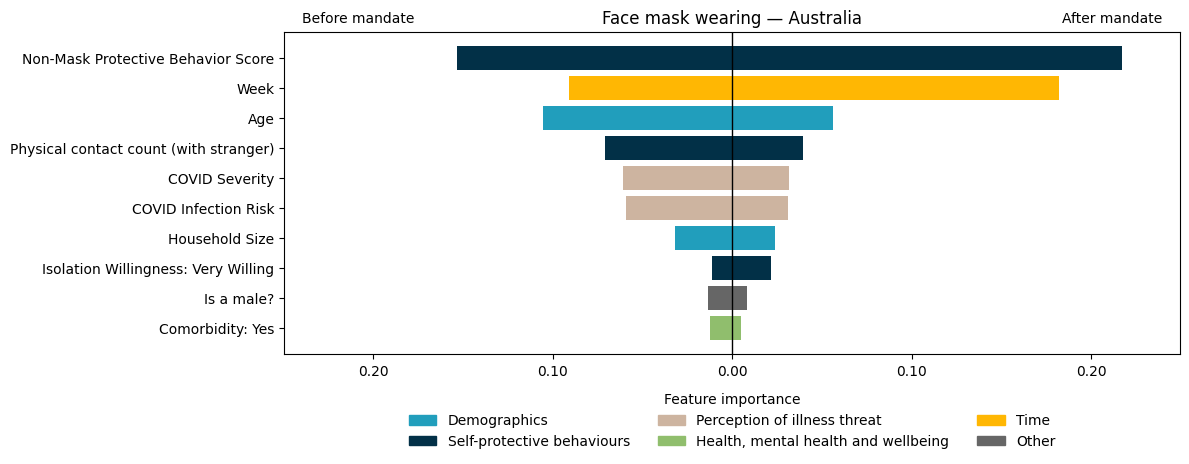

Saved


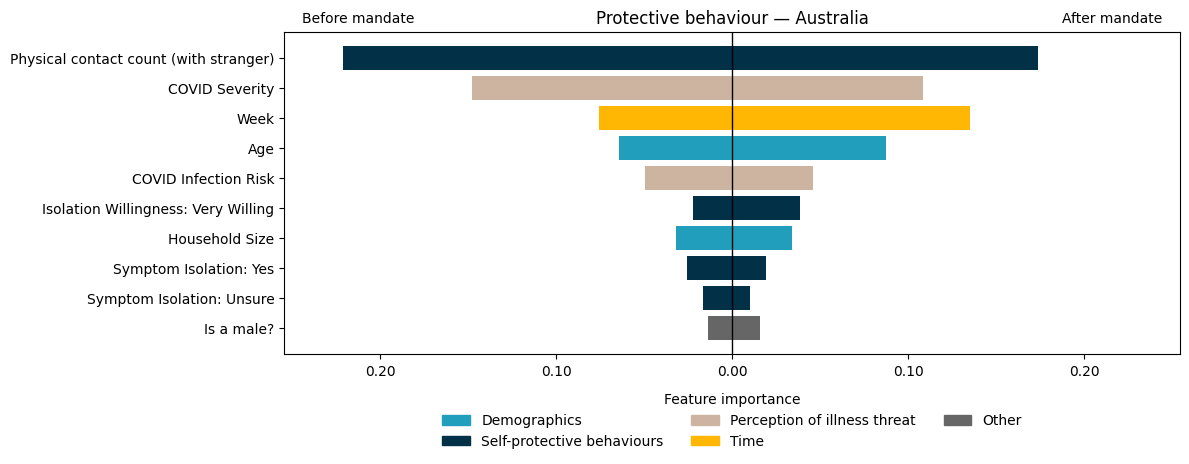

In [11]:
plot_feature_importance("Australia", "mask", top_n=10, save=SAVE_FIGURES)
plot_feature_importance("Australia", "protective", top_n=10, save=SAVE_FIGURES)

#### 3.2.3 Brazil

Saved


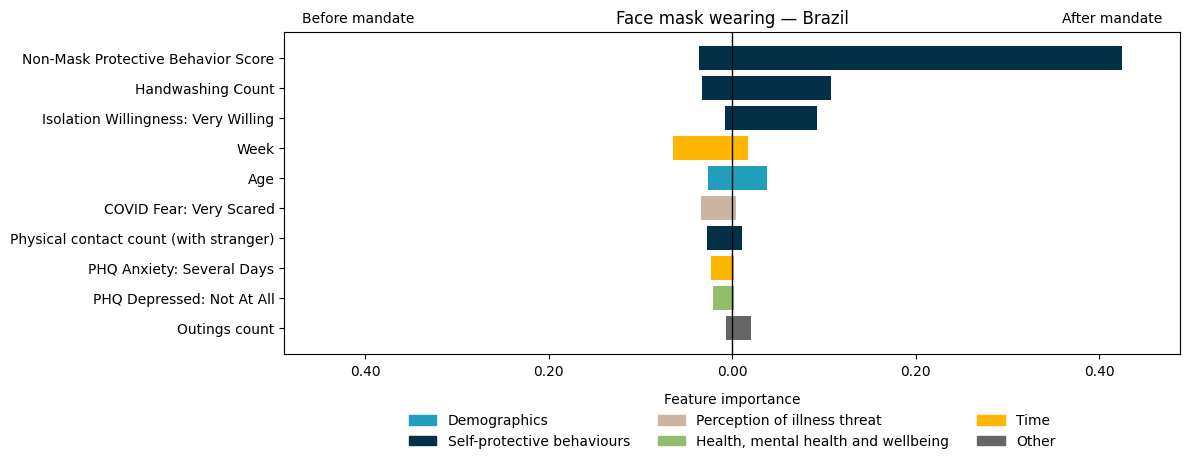

Saved


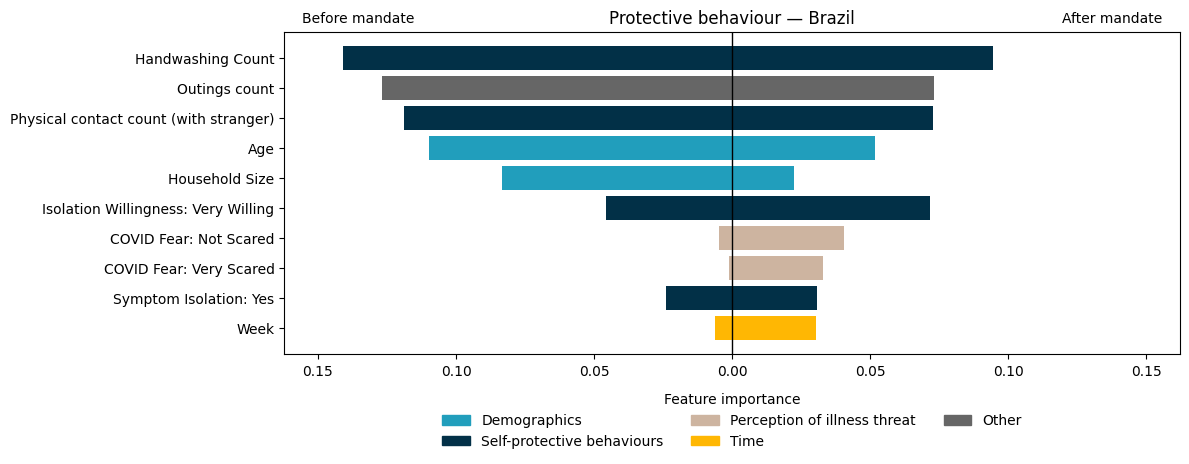

In [12]:
plot_feature_importance("Brazil", "mask", top_n=10, save=SAVE_FIGURES)
plot_feature_importance("Brazil", "protective", top_n=10, save=SAVE_FIGURES)

#### 3.2.4 Canada

Saved


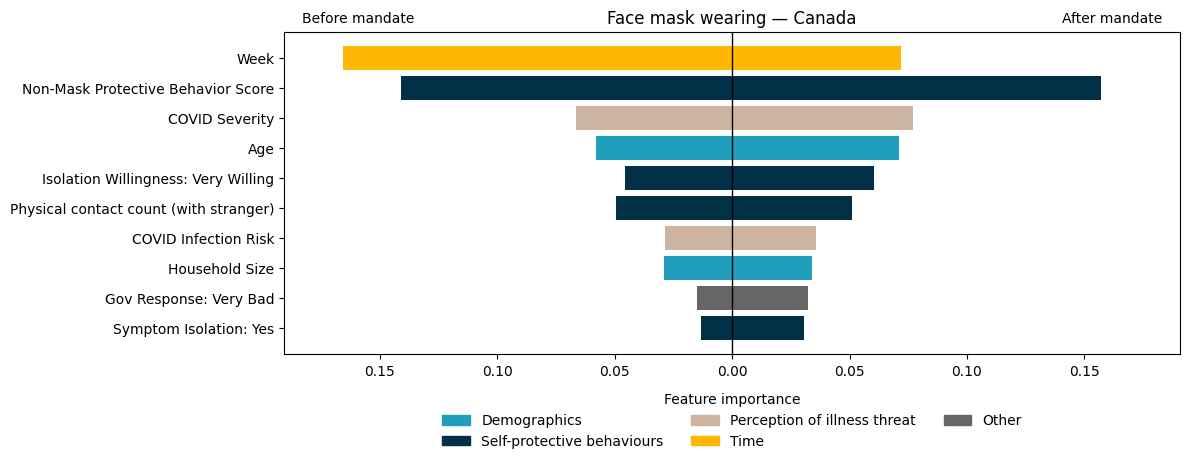

Saved


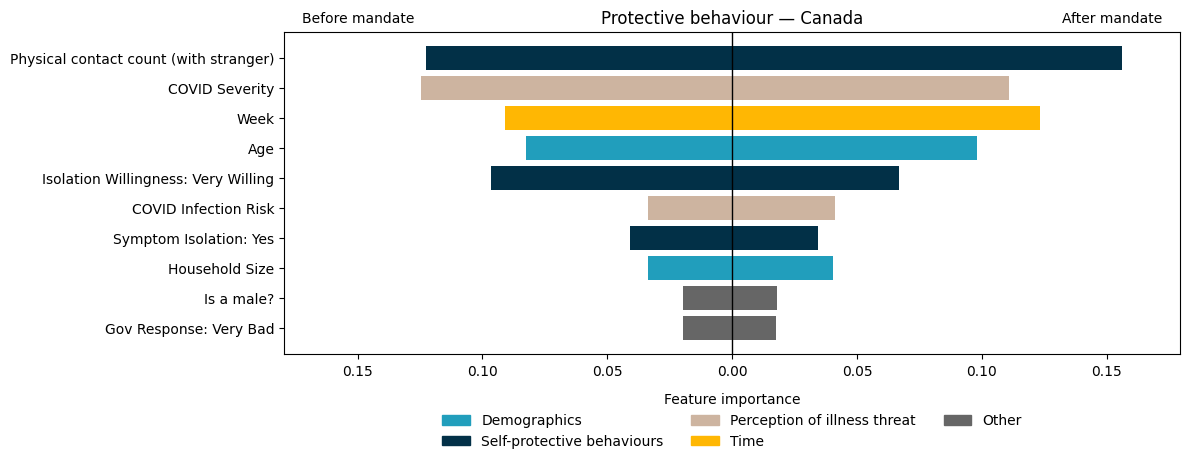

In [13]:
plot_feature_importance("Canada", "mask", top_n=10, save=SAVE_FIGURES)
plot_feature_importance("Canada", "protective", top_n=10, save=SAVE_FIGURES)

#### 3.2.5 United Kingdom

Saved


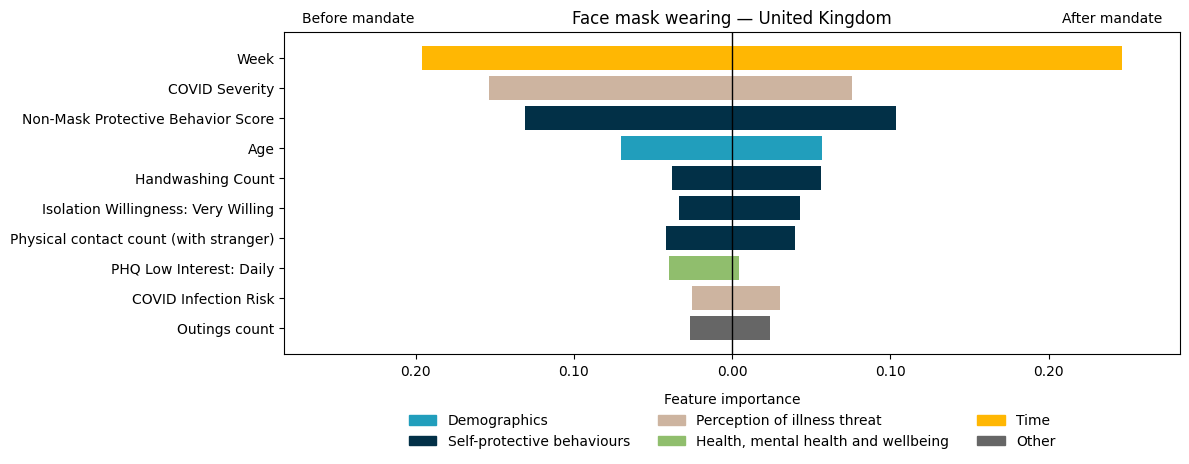

Saved


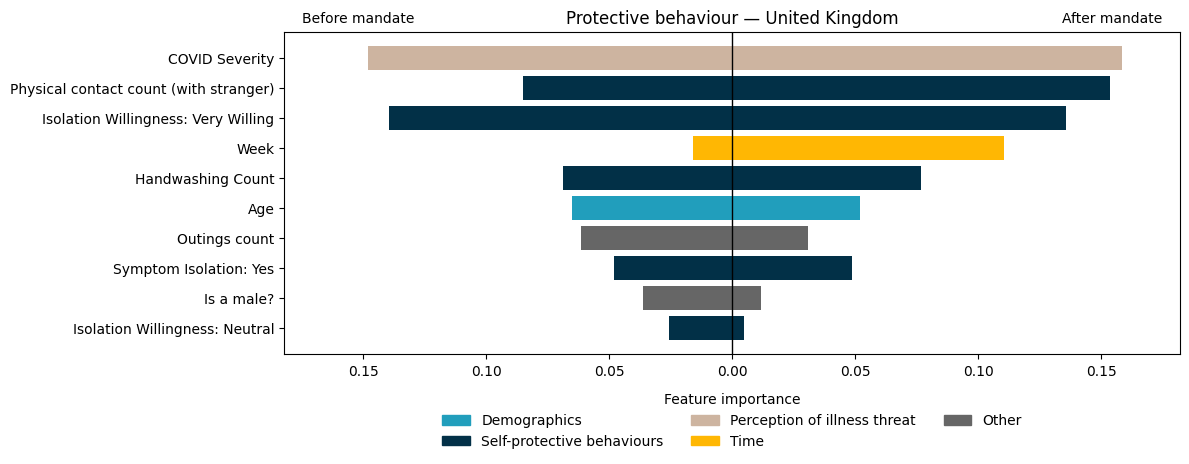

In [14]:
plot_feature_importance("United Kingdom", "mask", top_n=10, save=SAVE_FIGURES)
plot_feature_importance("United Kingdom", "protective", top_n=10, save=SAVE_FIGURES)

#### 3.2.6 India

Saved


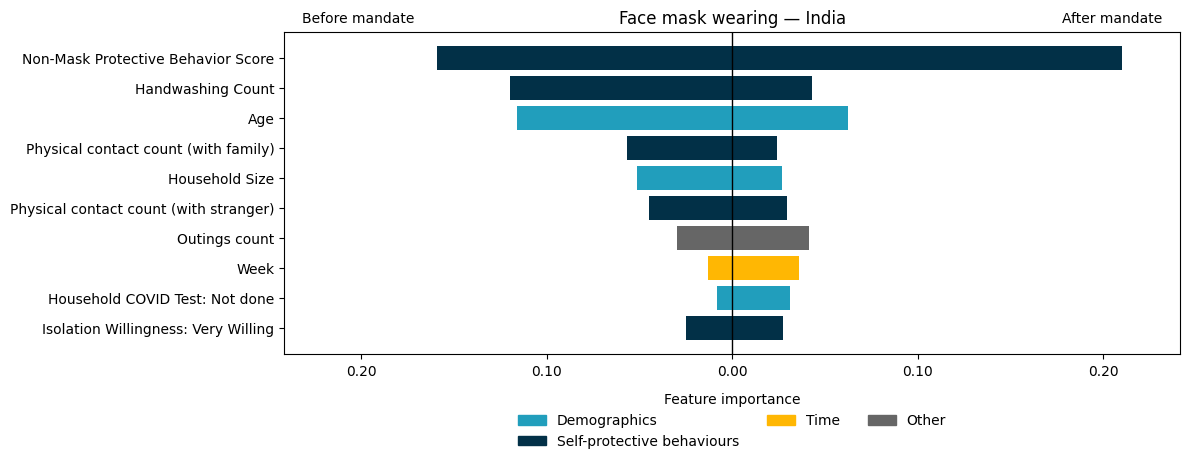

Saved


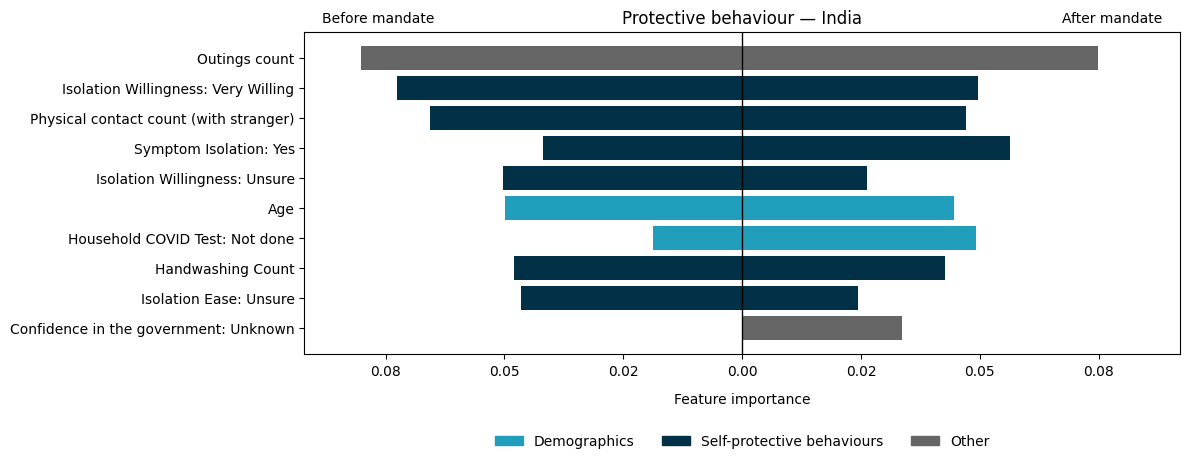

In [15]:
plot_feature_importance("India", "mask", top_n=10, save=SAVE_FIGURES)
plot_feature_importance("India", "protective", top_n=10, save=SAVE_FIGURES)

#### 3.2.7 United States

Saved


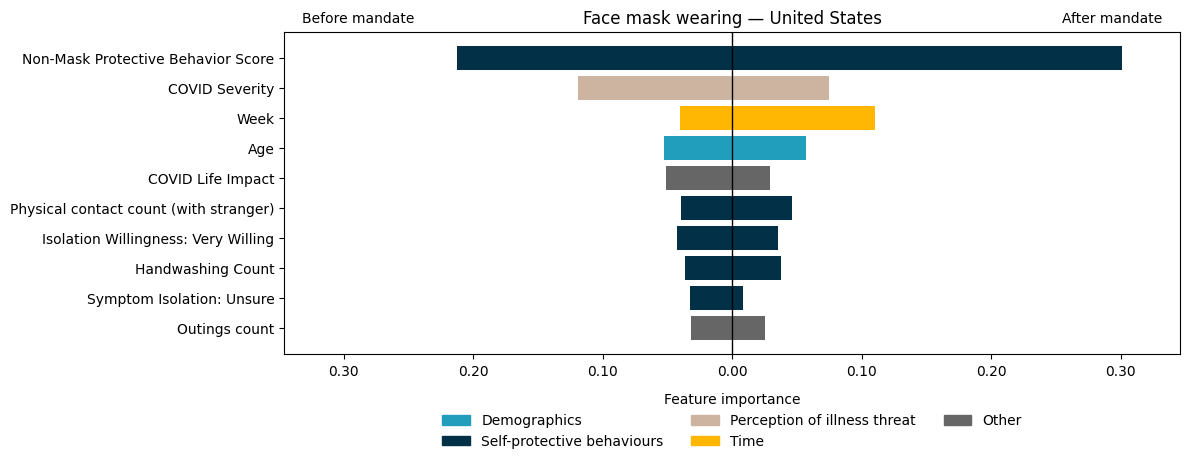

Saved


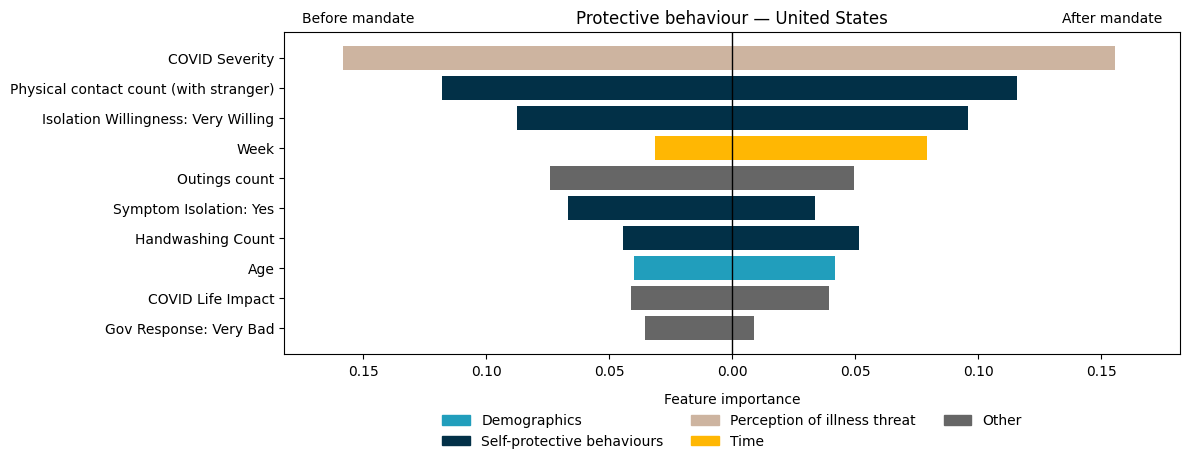

In [16]:
plot_feature_importance("United States", "mask", top_n=10, save=SAVE_FIGURES)
plot_feature_importance("United States", "protective", top_n=10, save=SAVE_FIGURES)